# Model 4: Genre & Keywords → Revenue

Bayesian linear regression with ARD-style priors over genre one-hots and keyword topic features.  
Output: posterior predictive **N(μ_genre, σ_genre²)** over log-revenue per movie.

Pipeline:
1. Load movies + keywords
2. Parse keywords → TF-IDF → SVD topics
3. Build feature matrix: genres + topics + runtime
4. Pyro model with group-level ARD priors
5. SVI training
6. Posterior predictive → (μ, σ) per movie

## 1. Imports & Settings

In [1]:
pip install pyro-ppl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer   # convert keyword text → sparse word-frequency matrix
from sklearn.decomposition import TruncatedSVD                # reduce TF-IDF matrix to dense topic vectors
from sklearn.preprocessing import StandardScaler              # zero-mean / unit-variance scaling
from sklearn.model_selection import train_test_split

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive            # SVI = stochastic variational inference; ELBO = training objective
from pyro.infer.autoguide import AutoNormal                   # mean-field Gaussian variational family (one μ/σ per latent)
from pyro.optim import ClippedAdam                            # Adam with gradient clipping for stable SVI

pyro.set_rng_seed(42)
torch.manual_seed(42)

DATA_DIR = Path('../data/')
N_KEYWORD_TOPICS = 20   # number of SVD latent topics extracted from keyword TF-IDF matrix
N_SVI_STEPS      = 3000 # total gradient steps for variational inference
LR               = 0.01 # learning rate for ClippedAdam optimizer

print(f"Pyro {pyro.__version__} | Torch {torch.__version__}")

## 2. Load Data

In [ ]:
# movies_metadata_slim.csv = filtered version with only the 7 columns this notebook needs
# (id, title, budget, revenue, runtime, genres, release_date) — 0.8 MB vs 34 MB original
movies_raw = pd.read_csv(DATA_DIR / 'movies_metadata_slim.csv')
keywords_raw = pd.read_csv(DATA_DIR / 'keywords.csv')

print(f"movies_metadata_slim : {movies_raw.shape}")
print(f"keywords             : {keywords_raw.shape}")

In [ ]:
# Load US CPI data to convert all money values to 2024 dollars
# Without inflation adjustment, a $10M film in 1980 looks tiny vs a $10M film in 2020
_cpi = pd.read_csv(
    DATA_DIR / 'United-States-Inflation-Rate-Consumer-Price-Index-2026-05-06-15-32.csv',
    sep=';', decimal=','
)
_cpi.columns = _cpi.columns.str.strip()
_cpi['year'] = pd.to_numeric(_cpi['year'], errors='coerce').astype('Int64')
_cpi['rate_factor'] = pd.to_numeric(_cpi['Inflation Rate'], errors='coerce') / 100 + 1
_cpi = _cpi.sort_values('year').reset_index(drop=True)

# deflator[year] = product of all (1 + inflation_rate) from that year to end of dataset
# multiplying revenue by deflator[year] scales it to the most-recent year's dollars
_cpi['deflator'] = _cpi['rate_factor'][::-1].cumprod()[::-1]
year_to_deflator = _cpi.set_index('year')['deflator'].to_dict()

print(f"CPI deflator loaded: {int(_cpi['year'].min())}–{int(_cpi['year'].max())}  "
      f"({len(year_to_deflator)} years)")

## 3. Clean Movies Metadata

In [ ]:
def parse_json_col(val):
    # genres/keywords columns are stored as Python-literal strings, not real JSON
    try:
        return ast.literal_eval(val)
    except:
        return []

movies = movies_raw.copy()
# Cast numeric columns — raw CSV has mixed types/strings
movies['budget']  = pd.to_numeric(movies['budget'],  errors='coerce')
movies['revenue'] = pd.to_numeric(movies['revenue'], errors='coerce')
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')
movies['id']      = pd.to_numeric(movies['id'],      errors='coerce')
movies['genres']  = movies['genres'].apply(parse_json_col)

# Extract release year for CPI adjustment
movies['year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year.astype('Int64')

# Scale budget and revenue to 2024 USD using the precomputed CPI deflator
movies['revenue_inflated'] = movies['revenue'] * movies['year'].map(year_to_deflator)
movies['budget_inflated']  = movies['budget']  * movies['year'].map(year_to_deflator)

# Drop rows where budget, revenue, or runtime is missing/zero — model can't use them
movies = movies[
    (movies['budget_inflated'] > 0) &
    (movies['revenue_inflated'] > 0) &
    (movies['runtime'] > 0)
]
movies = movies.dropna(subset=['budget_inflated', 'revenue_inflated', 'runtime', 'id'])
movies = movies.reset_index(drop=True)

# Log-transform targets and features — revenue/budget are right-skewed across orders of magnitude
movies['log_revenue'] = np.log(movies['revenue_inflated'])
movies['log_budget']  = np.log(movies['budget_inflated'])
movies['log_runtime'] = np.log(movies['runtime'])

print(f"Cleaned movies: {movies.shape[0]} rows  (revenue & budget in 2024 USD)")
movies[['title', 'year', 'revenue', 'revenue_inflated', 'log_revenue']].head()

## 4. Genre Features (One-Hot Weighted)

In [ ]:
from collections import Counter

# Count how often each genre appears across all movies
genre_counter = Counter()
for genre_list in movies['genres']:
    for g in genre_list:
        if isinstance(g, dict):
            genre_counter[g['name']] += 1

# Use only the 15 most common genres — rare genres have too few examples to learn from
TOP_GENRES = [name for name, _ in genre_counter.most_common(15)]
print("Top genres:", TOP_GENRES)

def genre_vector(genre_list, top_genres):
    names = {g['name'] for g in genre_list if isinstance(g, dict)}
    total = max(len(names), 1)
    # Divide by number of genres so each movie's genre features sum to 1
    # This prevents multi-genre movies from having artificially higher feature magnitudes
    return [1.0 / total if g in names else 0.0 for g in top_genres]

genre_matrix = np.array(
    [genre_vector(gl, TOP_GENRES) for gl in movies['genres']]
)

genre_df = pd.DataFrame(genre_matrix, columns=[f"genre_{g.lower().replace(' ','_')}" for g in TOP_GENRES])
print(f"Genre matrix: {genre_df.shape}")
genre_df.head(3)

## 5. Keyword Features (TF-IDF → SVD Topics)

In [ ]:
keywords_raw['id'] = pd.to_numeric(keywords_raw['id'], errors='coerce')
keywords_raw['keywords_parsed'] = keywords_raw['keywords'].apply(parse_json_col)

def kw_doc(kw_list):
    # Join all keyword names into one string per movie (spaces replaced with _ so each phrase is one token)
    return ' '.join(
        k['name'].replace(' ', '_')
        for k in kw_list if isinstance(k, dict)
    )

keywords_raw['kw_doc'] = keywords_raw['keywords_parsed'].apply(kw_doc)
kw_lookup = keywords_raw.set_index('id')['kw_doc'].to_dict()

# Attach keyword text to each movie row; fill missing with empty string
movies['kw_doc'] = movies['id'].map(kw_lookup).fillna('')

# TF-IDF: weight keywords by how distinctive they are across movies
# max_features=500 keeps vocabulary manageable; min_df=3 drops keywords seen in <3 movies
tfidf = TfidfVectorizer(max_features=500, min_df=3)
kw_tfidf = tfidf.fit_transform(movies['kw_doc'])

# SVD compresses the 500-dim sparse TF-IDF matrix into 20 dense latent topics
# Each topic captures a cluster of co-occurring keywords (e.g. "sequel + superhero + marvel")
svd = TruncatedSVD(n_components=N_KEYWORD_TOPICS, random_state=42)
kw_topics = svd.fit_transform(kw_tfidf)

kw_df = pd.DataFrame(
    kw_topics,
    columns=[f"kw_topic_{i}" for i in range(N_KEYWORD_TOPICS)]
)

print(f"Keyword topic matrix: {kw_df.shape}")
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")
kw_df.head(3)

## 6. Build Full Feature Matrix

In [ ]:
# Scale runtime to zero-mean/unit-variance — keeps it on the same scale as keyword topics
scaler_runtime = StandardScaler()
runtime_scaled = scaler_runtime.fit_transform(movies[['log_runtime']])

# Scale keyword topics — SVD components can have very different magnitudes across topics
scaler_kw = StandardScaler()
kw_scaled = scaler_kw.fit_transform(kw_df.values)

# Genre features are already in [0,1] (normalized by genre count) — no further scaling needed
X_genre   = genre_df.values.astype(np.float32)   # (N, 15) — one-hot weighted genre indicators
X_kw      = kw_scaled.astype(np.float32)          # (N, 20) — latent keyword topics
X_runtime = runtime_scaled.astype(np.float32)     # (N, 1)  — standardized log-runtime
y_log_rev = movies['log_revenue'].values.astype(np.float32)  # regression target

N = X_genre.shape[0]
print(f"Total samples : {N}")
print(f"Genre features: {X_genre.shape[1]}")
print(f"KW topics     : {X_kw.shape[1]}")
print(f"Target range  : [{y_log_rev.min():.2f}, {y_log_rev.max():.2f}]")

In [ ]:
# 80/20 train-test split — test set is held out to measure out-of-sample RMSE
idx = np.arange(N)
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42)

def to_torch(arr, idx):
    return torch.tensor(arr[idx])

# Create PyTorch tensors for each feature group, separately for train and test
Xg_tr, Xg_te       = to_torch(X_genre, tr_idx),   to_torch(X_genre, te_idx)
Xk_tr, Xk_te       = to_torch(X_kw,   tr_idx),    to_torch(X_kw,   te_idx)
Xr_tr, Xr_te       = to_torch(X_runtime, tr_idx), to_torch(X_runtime, te_idx)
y_tr,  y_te         = to_torch(y_log_rev, tr_idx), to_torch(y_log_rev, te_idx)

print(f"Train: {len(tr_idx)}  |  Test: {len(te_idx)}")

## 7. Pyro Model — ARD Bayesian Regression

Each feature group gets its own scale prior (ARD-style).  
High-σ group = more flexible = model trusts that group more.

```
σ_genre  ~ HalfNormal(5)
β_genre  ~ Normal(0, σ_genre)   [15 weights]

σ_kw     ~ HalfNormal(2)
β_kw     ~ Normal(0, σ_kw)      [20 weights]

β_runtime ~ Normal(0, 2)
intercept ~ Normal(14, 3)        [log-revenue ≈ 14–20]

σ_obs    ~ HalfNormal(1)

μ = intercept + X_genre @ β_genre + X_kw @ β_kw + X_runtime * β_runtime
log_revenue ~ Normal(μ, σ_obs)
```

In [ ]:
N_GENRE = X_genre.shape[1]   # 15
N_KW    = X_kw.shape[1]      # 20

def model(X_genre, X_kw, X_runtime, y=None):
    n = X_genre.shape[0]

    # Global intercept centred on typical log-revenue (~14–20 range)
    intercept  = pyro.sample("intercept",  dist.Normal(14., 3.))

    # ARD-style prior for genre weights:
    # sigma_genre is shared across all 15 genre betas — it controls how much the model
    # trusts genre information overall. If sigma_genre is large, genre betas can be large.
    sigma_genre = pyro.sample("sigma_genre", dist.HalfNormal(5.))
    beta_genre  = pyro.sample("beta_genre",
                              dist.Normal(torch.zeros(N_GENRE),
                                          sigma_genre * torch.ones(N_GENRE)).to_event(1))

    # ARD-style prior for keyword topic weights (tighter prior than genre — HalfNormal(2))
    sigma_kw = pyro.sample("sigma_kw", dist.HalfNormal(2.))
    beta_kw  = pyro.sample("beta_kw",
                           dist.Normal(torch.zeros(N_KW),
                                       sigma_kw * torch.ones(N_KW)).to_event(1))

    # Runtime gets a simple fixed prior — less domain uncertainty here
    beta_runtime = pyro.sample("beta_runtime", dist.Normal(0., 2.))

    # Observation noise — how much unexplained variance remains after all features
    sigma_obs = pyro.sample("sigma_obs", dist.HalfNormal(1.))

    # Linear predictor: intercept + genre contribution + keyword contribution + runtime
    mu = (intercept
          + X_genre   @ beta_genre
          + X_kw      @ beta_kw
          + X_runtime.squeeze(-1) * beta_runtime)

    # Likelihood: each movie's log-revenue is Normal around the linear predictor
    with pyro.plate("data", n):
        pyro.sample("obs", dist.Normal(mu, sigma_obs), obs=y)

## 8. SVI Training

In [ ]:
pyro.clear_param_store()  # reset any leftover variational parameters from previous runs

# AutoNormal automatically creates one variational mean + variance per latent variable
guide = AutoNormal(model)

# ClippedAdam: standard Adam but gradients are clipped to prevent exploding updates
optimizer = ClippedAdam({"lr": LR, "clip_norm": 5.0})

# SVI minimises the negative ELBO = KL(q||p) - E_q[log p(data|θ)]
# Maximising ELBO = fitting the data well + keeping posteriors close to priors
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

losses = []
print(f"Training SVI for {N_SVI_STEPS} steps...")
for step in range(N_SVI_STEPS):
    loss = svi.step(Xg_tr, Xk_tr, Xr_tr, y_tr)  # one gradient step on the full training set
    losses.append(loss)
    if step % 500 == 0:
        print(f"  step {step:4d}  ELBO loss: {loss:.2f}")

print("Done.")

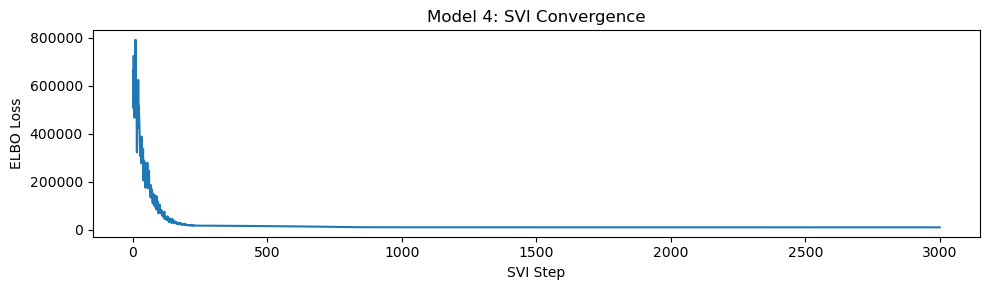

In [12]:
plt.figure(figsize=(10, 3))
plt.plot(losses)
plt.xlabel("SVI Step")
plt.ylabel("ELBO Loss")
plt.title("Model 4: SVI Convergence")
plt.tight_layout()
plt.show()

## 9. Posterior Predictive — Output N(μ, σ²)

In [ ]:
N_SAMPLES = 500  # number of posterior samples drawn to approximate the predictive distribution

# Predictive draws N_SAMPLES sets of parameters from the guide (variational posterior),
# then runs the model forward to get a distribution over log-revenue
predictive = Predictive(model, guide=guide, num_samples=N_SAMPLES,
                        return_sites=["obs", "sigma_genre", "sigma_kw",
                                      "beta_genre", "beta_kw",
                                      "intercept", "sigma_obs"])

# Run posterior predictive on train and test sets (no gradient needed at inference time)
with torch.no_grad():
    post_tr = predictive(Xg_tr, Xk_tr, Xr_tr)
    post_te = predictive(Xg_te, Xk_te, Xr_te)

# obs shape: (N_SAMPLES, n_movies) — average over samples to get point estimate and uncertainty
mu_tr = post_tr["obs"].mean(0).numpy()   # posterior predictive mean per training movie
sd_tr = post_tr["obs"].std(0).numpy()    # posterior predictive std  per training movie

mu_te = post_te["obs"].mean(0).numpy()   # posterior predictive mean per test movie
sd_te = post_te["obs"].std(0).numpy()    # posterior predictive std  per test movie

print("Posterior predictive computed.")
print(f"Test  μ range: [{mu_te.min():.2f}, {mu_te.max():.2f}]")
print(f"Test  σ range: [{sd_te.min():.3f}, {sd_te.max():.3f}]")

## 10. Evaluate — RMSE on log-revenue

In [ ]:
rmse_train = np.sqrt(np.mean((mu_tr - y_tr.numpy())**2))
rmse_test  = np.sqrt(np.mean((mu_te - y_te.numpy())**2))

# Log-likelihood measures how well the model's full distribution (not just mean) fits the data
# Higher = better; accounts for both accuracy (μ) and calibration (σ)
from scipy.stats import norm
log_lik = norm.logpdf(y_te.numpy(), loc=mu_te, scale=sd_te).mean()

print(f"RMSE (log-revenue) — Train : {rmse_train:.4f}")
print(f"RMSE (log-revenue) — Test  : {rmse_test:.4f}")
print(f"Mean log-likelihood (test) : {log_lik:.4f}")

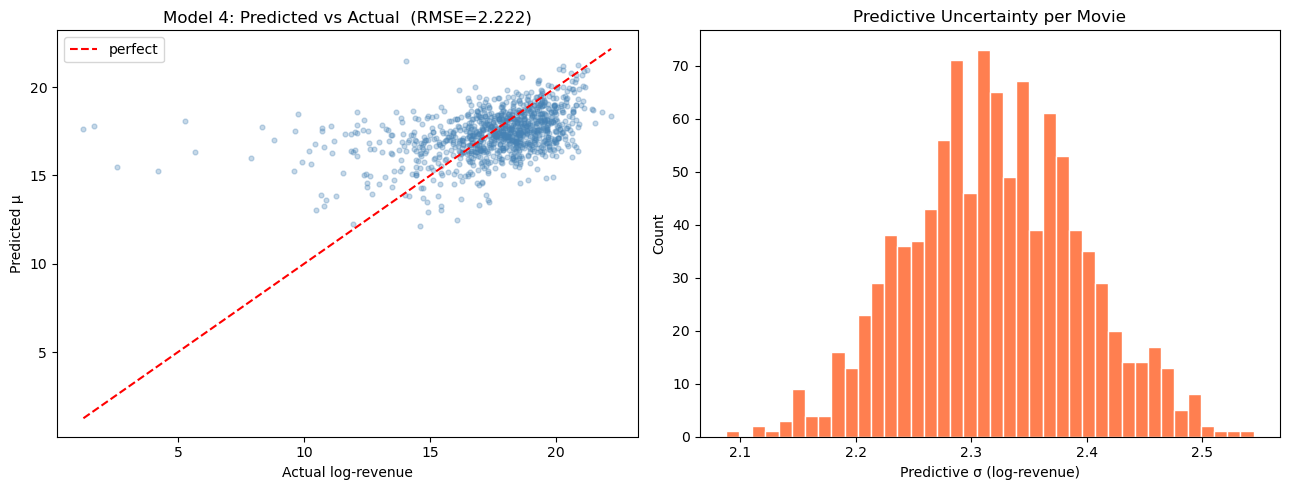

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual
ax = axes[0]
ax.scatter(y_te.numpy(), mu_te, alpha=0.3, s=12, color='steelblue')
lo, hi = y_te.numpy().min(), y_te.numpy().max()
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='perfect')
ax.set_xlabel("Actual log-revenue")
ax.set_ylabel("Predicted μ")
ax.set_title(f"Model 4: Predicted vs Actual  (RMSE={rmse_test:.3f})")
ax.legend()

# Uncertainty distribution
ax = axes[1]
ax.hist(sd_te, bins=40, color='coral', edgecolor='white')
ax.set_xlabel("Predictive σ (log-revenue)")
ax.set_ylabel("Count")
ax.set_title("Predictive Uncertainty per Movie")

plt.tight_layout()
plt.show()

## 11. What Did the Model Learn? — Genre Weights

In [ ]:
# Extract genre weight samples from the posterior predictive object — shape (N_SAMPLES, N_GENRE)
beta_genre_samples = post_te["beta_genre"].numpy()

# Baseline = training mean revenue (2024 USD)
# exp(mean log-revenue) = geometric mean revenue of training movies
baseline_revenue = np.exp(y_tr.numpy().mean())
print(f"Training baseline revenue: ${baseline_revenue/1e6:.1f}M")

# Convert log-revenue betas → dollar effect relative to baseline
# If log-revenue changes by β, revenue changes by baseline * (exp(β) - 1)
# Transform each posterior sample so uncertainty propagates correctly
revenue_effect_samples = baseline_revenue * (np.exp(beta_genre_samples) - 1)  # (N_SAMPLES, N_GENRE)
revenue_effect_mean = revenue_effect_samples.mean(0).flatten()   # posterior mean $ effect per genre
revenue_effect_std  = revenue_effect_samples.std(0).flatten()    # posterior std  $ effect per genre

genre_weight_df = pd.DataFrame({
    'genre'         : TOP_GENRES,
    'mean_β'        : beta_genre_samples.mean(0).flatten(),      # keep raw β for reference
    'revenue_effect': revenue_effect_mean,
    'revenue_std'   : revenue_effect_std,
    'lower'         : revenue_effect_mean - 2 * revenue_effect_std,
    'upper'         : revenue_effect_mean + 2 * revenue_effect_std,
}).sort_values('revenue_effect', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['green' if m > 0 else 'red' for m in genre_weight_df['revenue_effect']]
# Error bars show ±2σ in revenue space — if bar crosses 0, that genre's effect is uncertain
ax.barh(genre_weight_df['genre'], genre_weight_df['revenue_effect'] / 1e6,
        xerr=2 * genre_weight_df['revenue_std'] / 1e6, color=colors, alpha=0.7,
        capsize=4, ecolor='gray')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel(f"Revenue effect vs baseline (${baseline_revenue/1e6:.0f}M train mean)  [$ millions]")
ax.set_title("Model 4: Posterior Genre Revenue Effects (±2σ)")
plt.tight_layout()
plt.show()

genre_weight_df[['genre', 'revenue_effect', 'revenue_std', 'lower', 'upper']].assign(
    **{c: genre_weight_df[c] / 1e6 for c in ['revenue_effect', 'revenue_std', 'lower', 'upper']}
).rename(columns=lambda c: c + '_$M' if c != 'genre' else c)

## 12. Keyword Topic Weights

In [ ]:
# Extract keyword topic weight samples — shape (N_SAMPLES, N_KW)
beta_kw_samples = post_te["beta_kw"].numpy()
beta_kw_mean = beta_kw_samples.mean(0).flatten()
beta_kw_std  = beta_kw_samples.std(0).flatten()

# Show top 5 keywords per SVD topic so we can interpret what each topic represents
feature_names = tfidf.get_feature_names_out()
components = svd.components_   # shape (N_KW, vocab_size) — each row is one topic

print("Top keywords per topic:")
for i in range(N_KEYWORD_TOPICS):
    top_kw = [feature_names[j] for j in components[i].argsort()[-5:][::-1]]
    sign   = "+" if beta_kw_mean[i] > 0 else "-"
    # β sign tells whether this topic's presence helps (+) or hurts (-) predicted revenue
    print(f"  Topic {i:2d} [{sign} β={beta_kw_mean[i]:+.3f}]: {', '.join(top_kw)}")

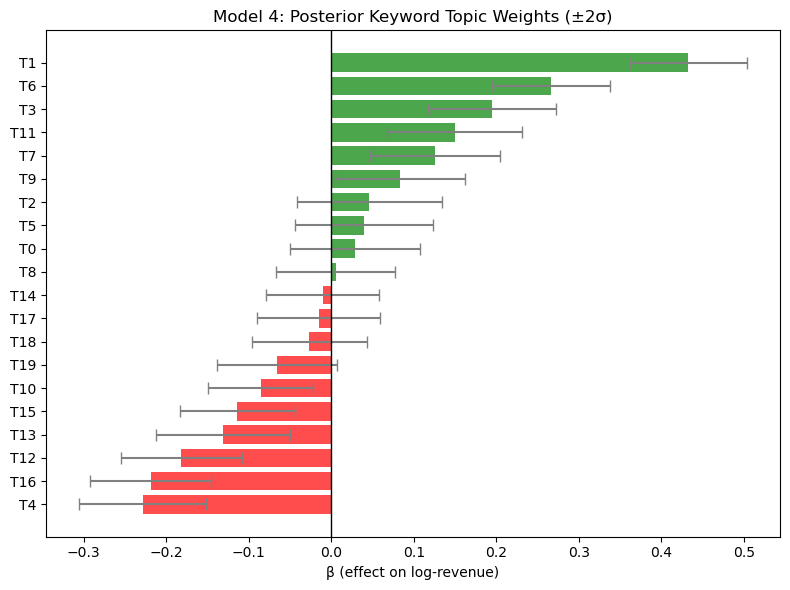

In [18]:
kw_topic_labels = [f"T{i}" for i in range(N_KEYWORD_TOPICS)]

kw_weight_df = pd.DataFrame({
    'topic'  : kw_topic_labels,
    'mean_β' : beta_kw_mean,
    'std_β'  : beta_kw_std,
}).sort_values('mean_β', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['green' if m > 0 else 'red' for m in kw_weight_df['mean_β']]
ax.barh(kw_weight_df['topic'], kw_weight_df['mean_β'],
        xerr=2 * kw_weight_df['std_β'], color=colors, alpha=0.7,
        capsize=4, ecolor='gray')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel("β (effect on log-revenue)")
ax.set_title("Model 4: Posterior Keyword Topic Weights (±2σ)")
plt.tight_layout()
plt.show()

## 13. Export Posterior Predictive — N(μ, σ²) per Movie

This is the output fed into the Bayesian aggregator (precision-weighted fusion).

In [ ]:
# Run posterior predictive on ALL 5190 movies (not just train/test split)
# This full-dataset output is what gets fed into the Bayesian aggregator
Xg_all = torch.tensor(X_genre)
Xk_all = torch.tensor(X_kw)
Xr_all = torch.tensor(X_runtime)

with torch.no_grad():
    post_all = predictive(Xg_all, Xk_all, Xr_all)

mu_all = post_all["obs"].mean(0).numpy()   # posterior predictive mean per movie
sd_all = post_all["obs"].std(0).numpy()    # posterior predictive std  per movie

model4_output = pd.DataFrame({
    'id'            : movies['id'].values,
    'title'         : movies['title'].values,
    'log_revenue'   : movies['log_revenue'].values,
    'mu_genre'      : mu_all,
    'sigma_genre'   : sd_all,
    # precision = 1/σ² — used as weight in the precision-weighted Bayesian fusion formula
    # higher precision = model is more confident = gets more weight in aggregation
    'precision_genre': 1.0 / (sd_all ** 2),
})

model4_output.to_csv(DATA_DIR / 'model4_posterior.csv', index=False)
print(f"Saved model4_posterior.csv — {model4_output.shape[0]} movies")
model4_output.head(10)

## 14. Summary

| Output | Meaning |
|--------|----------|
| `mu_genre` | Posterior mean log-revenue prediction from genre+keywords |
| `sigma_genre` | Posterior std — uncertainty of this model |
| `precision_genre` | `1/σ²` — weight in precision-weighted Bayesian fusion |

**Aggregator formula (product of experts):**
```
σ_agg² = 1 / Σ_i (1/σ_i²)
μ_agg  = σ_agg² · Σ_i (μ_i / σ_i²)
```
Model 4 contributes one term. High σ_genre → low weight in aggregation → model self-reports low confidence.